# Vakuumtechnik

Steigung
Luft: 9.979081e-05 +/- 4.329485e-08 torr/s
Helium: 1.205449e-04 +/- 1.187373e-07 torr/s
Leckrate
Luft: 8.626915e-04 +/- 6.673517e-05 mbar l/s
Helium: 1.042110e-03 +/- 8.118881e-05 mbar l/s


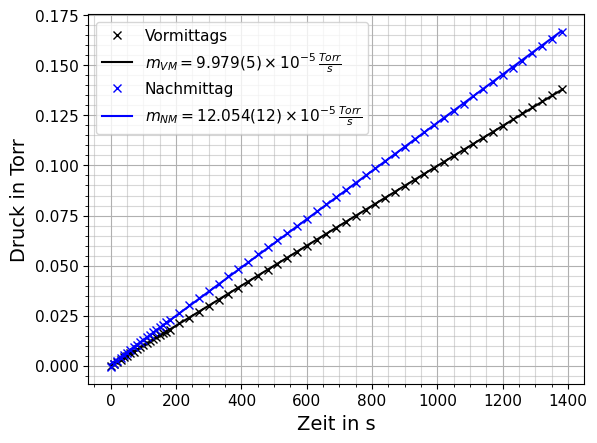

In [12]:
# Leckratenbestimmung
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

V_fehler = 0.5

def slope_to_leckrate(slope):
    "slope in torr/s"
    return slope*1.33*6.5 # mbar l/s

def leckfehler(slope, slopefehl, volfehl):
    "slope in torr/s, slopefehl in torr/s, volfehl in l"
    return slope*1.33*volfehl + 1.33*6.5*slopefehl # mbar l/s

#data loading
zeit, leckluft, leckhe= np.loadtxt(r'../Messdaten/20260427_Vakuum/leckrate.csv', skiprows=1, unpack=True, delimiter=',')

#modelling
fitluft = linregress(zeit, leckluft)
fithe = linregress(zeit, leckhe)

print("Steigung")
print(f"Luft: {fitluft.slope:e} +/- {fitluft.stderr:e} torr/s")
print(f"Helium: {fithe.slope:e} +/- {fithe.stderr:e} torr/s")

Qluft = (slope_to_leckrate(fitluft.slope), leckfehler(fitluft.slope, fitluft.stderr, V_fehler))
Qhe = (slope_to_leckrate(fithe.slope), leckfehler(fithe.slope, fithe.stderr, V_fehler))

print("Leckrate")
print(f"Luft: {Qluft[0]:e} +/- {Qluft[1]:e} mbar l/s")
print(f"Helium: {Qhe[0]:e} +/- {Qhe[1]:e} mbar l/s")

#plotting
def plotleck(fig, ax): # damit ich mit ax und fig arbeiten kann, die achsen später aber eindeutige namen haben
    ax.plot(zeit, leckluft, "xk", label="Vormittags")
    ax.plot(zeit, fitluft.intercept+fitluft.slope*zeit, "-k", label=r"$m_{VM}=9.979(5)\times10^{-5}\,\frac{Torr}{s}$")
    
    ax.plot(zeit, leckhe, "xb", label="Nachmittag")
    ax.plot(zeit, fithe.intercept+fithe.slope*zeit, "-b", label=r"$m_{NM}=12.054(12)\times10^{-5}\,\frac{Torr}{s}$")

    ax.set_xlabel("Zeit in s", fontsize=14)
    ax.set_ylabel("Druck in Torr", fontsize=14)
    ax.tick_params(labelsize=11)

    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend(fontsize=11)

    #plt.savefig(r"../Bilder/Vakuum/Leckraten.pdf")

leckfig, leckax = plt.subplots() # eindeutige Namen für ax und fig
plotleck(leckfig, leckax)

#Leckrate nachmittags höher, da gas durch mehrfaches 15torr hochpumpen an wand adsorbiert und interne leckrate steigt

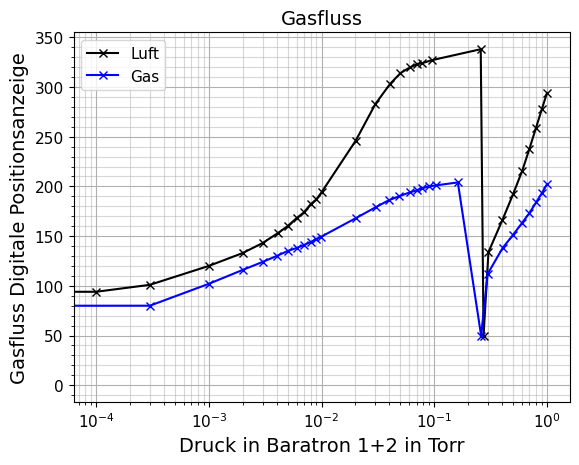

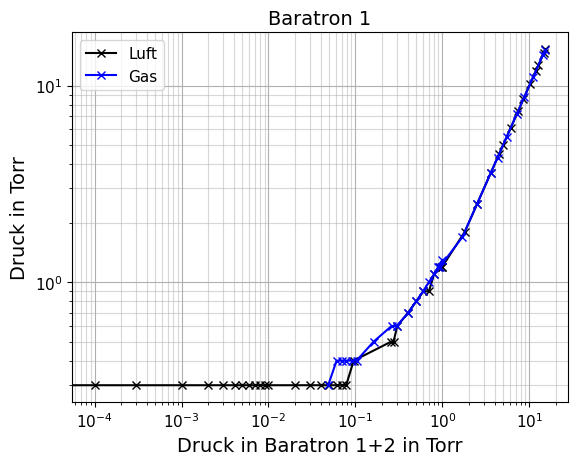

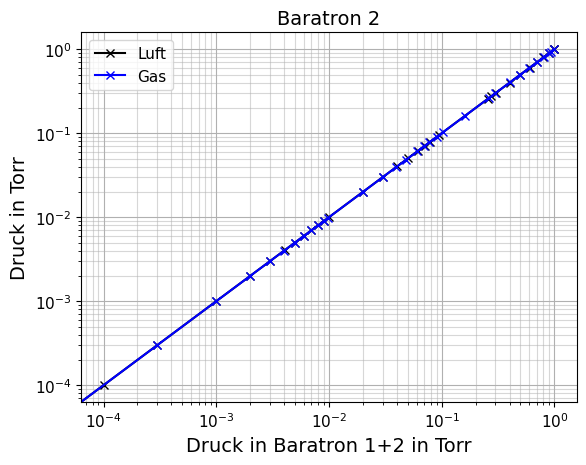

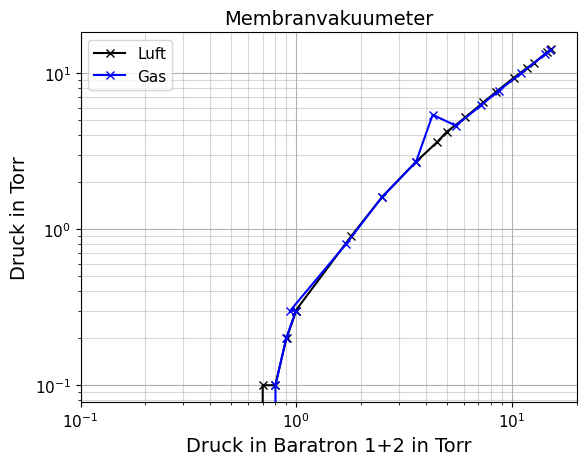

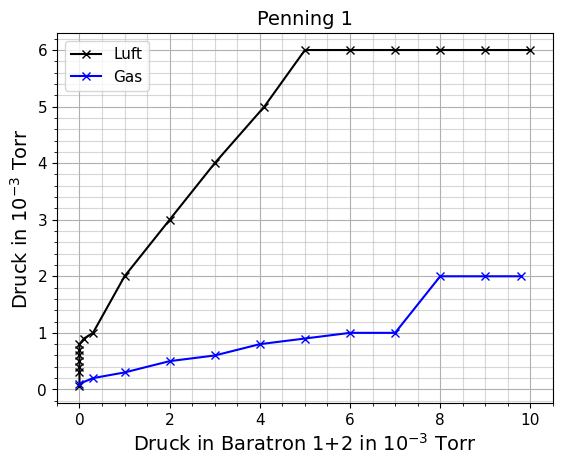

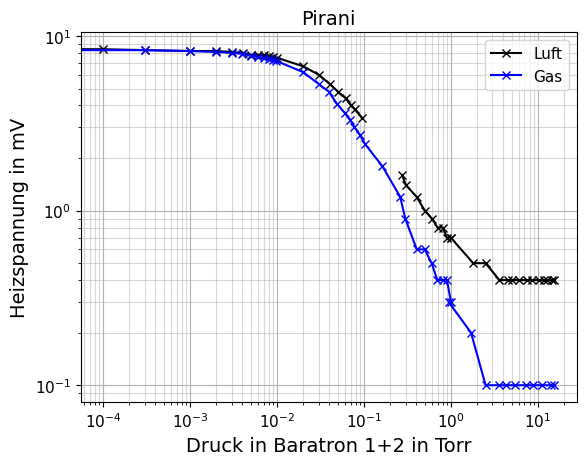

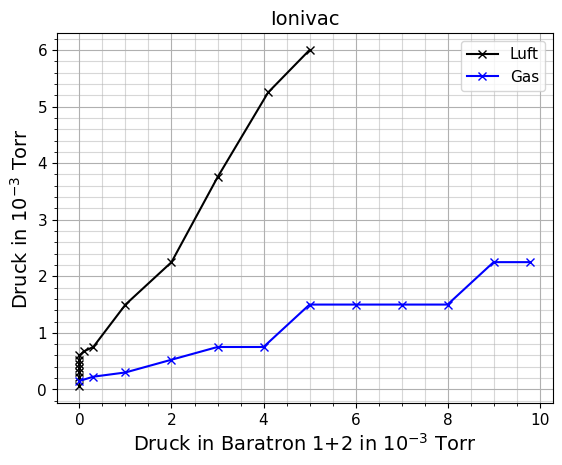

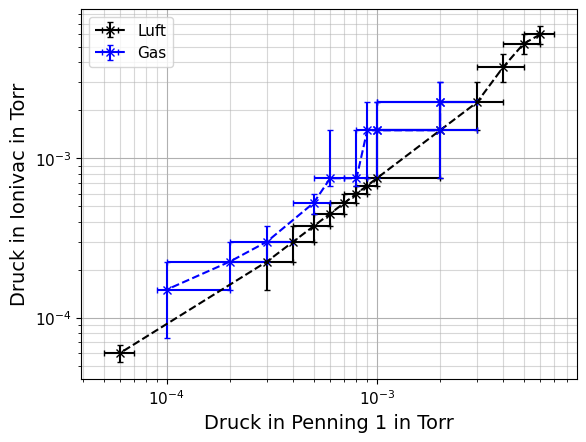

In [13]:
# Charakterisierung Druckmessköpfe
import numpy as np
import matplotlib.pyplot as plt

dv, bar1, bar2, mem, pen1, pir, ioni = np.genfromtxt(r'../Messdaten/20260427_Vakuum/druckmesskopfkennlinie_luft.csv', skip_header=1, unpack=True, delimiter=',', missing_values="", filling_values=np.nan)
luft = (dv, bar1, bar2, mem, pen1, pir/10, ioni*0.75) # ionivac in Torr statt mbar

dv, bar1, bar2, mem, pen1, pir, ioni = np.genfromtxt(r'../Messdaten/20260427_Vakuum/druckmesskopfkennlinie_he.csv', skip_header=1, unpack=True, delimiter=',', missing_values="", filling_values=np.nan)
he = (dv, bar1, bar2, mem, pen1, pir/10, ioni*0.75) # pirani in mV statt 0.1 mV


xluft = np.append(luft[1][:13], luft[2][13:])
xhe = np.append(he[1][:10], he[2][10:])

meter = {"Gasfluss":(luft[0], he[0]),
        "Baratron 1":(luft[1], he[1]),
        "Baratron 2":(luft[2], he[2]),
        "Membranvakuumeter":(luft[3], he[3]),
        "Penning 1":(luft[4], he[4]),
        "Pirani":(luft[5], he[5]),
        "Ionivac":(luft[6], he[6])}

for key in meter.keys():
    fig, ax = plt.subplots()
    if key == "Ionivac" or key == "Penning 1":
        ax.plot(xluft*1e3, meter[key][0]*1e3, "x-k", label="Luft")
        ax.plot(xhe*1e3, meter[key][1]*1e3, "x-b", label="Gas")
    else:
        ax.plot(xluft, meter[key][0], "x-k", label="Luft")
        ax.plot(xhe, meter[key][1], "x-b", label="Gas")
    if key == "Gasfluss":
        ax.set_xscale("log")
    elif key == "Penning 1" or key == "Ionivac":
        #ax.set_yscale("log")
        pass
    else:
        ax.loglog()

    if key == "Membranvakuumeter":
        ax.set_xlim(1e-1,20)

    ax.set_title(key, fontsize=14)

    ax.set_xlabel("Druck in Baratron 1+2 in Torr", fontsize=14)
    if key == "Pirani":
        ax.set_ylabel("Heizspannung in mV", fontsize=14)
    elif key == "Gasfluss":
        ax.set_ylabel("Gasfluss Digitale Positionsanzeige", fontsize=14)
    elif key == "Ionivac" or key == "Penning 1":
        ax.set_ylabel(r"Druck in $10^{-3}$ Torr", fontsize=14)
        ax.set_xlabel(r"Druck in Baratron 1+2 in $10^{-3}$ Torr", fontsize=14)
    else:
        ax.set_ylabel("Druck in Torr", fontsize=14)
    ax.tick_params(labelsize=11)

    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend(fontsize=11)

    #fig.savefig(f"../Bilder/Vakuum/{key}.pdf")

ionerr = (np.array(
            [(51-5-8-1)*[np.nan]+5*[1e-3]+8*[1e-4]+[1e-5],
           (51-6-7-1)*[np.nan]+6*[1e-3]+7*[1e-4]+[1e-5]])*0.75, # Luft
          np.array(
          [(42-6-6)*[np.nan]+6*[1e-3]+6*[1e-4],
           (42-8-4)*[np.nan]+8*[1e-3]+4*[1e-4]])*0.75) # Gas

penerr = ([(51-10-8-1)*[np.nan]+10*[1e-3]+8*[1e-4]+[1e-5],
           (51-11-7-1)*[np.nan]+11*[1e-3]+7*[1e-4]+[1e-5]],
          [(42-3-8-1)*[np.nan]+3*[1e-3]+8*[1e-4]+[1e-5],
           (42-5-7)*[np.nan]+5*[1e-3]+7*[1e-4]])

iopenfig, iopenax = plt.subplots()
iopenax.errorbar(meter["Penning 1"][0], meter["Ionivac"][0], xerr=penerr[0], yerr=ionerr[0], fmt="x--k", label="Luft", capsize=2)
iopenax.errorbar(meter["Penning 1"][1], meter["Ionivac"][1], xerr=penerr[1], yerr=ionerr[1], fmt="x--b", label="Gas", capsize=2)

iopenax.loglog()

iopenax.set_xlabel("Druck in Penning 1 in Torr", fontsize=14)
iopenax.set_ylabel("Druck in Ionivac in Torr", fontsize=14)
iopenax.tick_params(labelsize=11)

iopenax.minorticks_on()
iopenax.grid(which='major')
iopenax.grid(which='minor', alpha=0.5)
iopenax.legend(fontsize=11)

#iopenfig.savefig(f"../Bilder/Vakuum/Penning_vs_Ionivac.pdf")



Penning Luft: 1.000000e+00 +/- 1.216675e-08
Penning Gas: 6.578947e+00 +/- 4.385965e-01


Ionivac Luft: 8.205128e-01 +/- 5.921541e-02
Ionivac Gas: 3.222836e+00 +/- 7.938930e-01



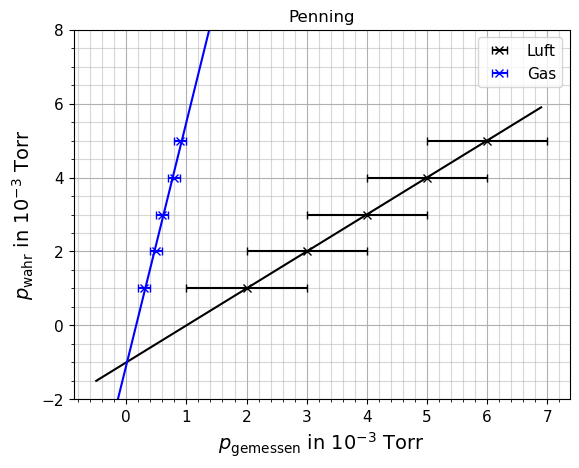

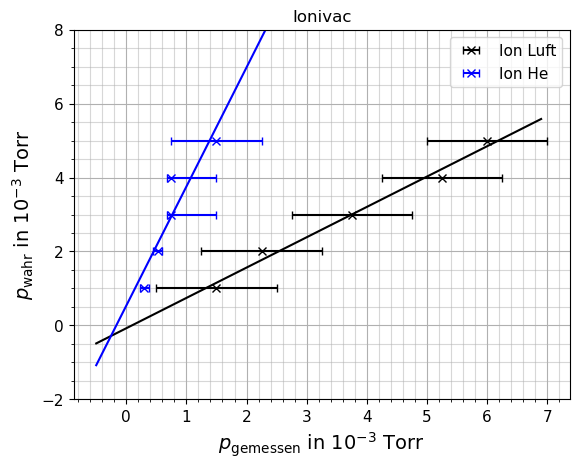

In [14]:
# Bestimmung des Korrekturfaktors inkl. Fehler
# p_wahr = p_Anzeige * Faktor
# Faktor(N2) = 1

from scipy.stats import linregress
import numpy as np

penning = (np.array([6e-3, 5e-3, 4e-3, 3e-3, 2e-3]), np.array([9e-4, 8e-4, 6e-4, 5e-4, 3e-4]))
ionivac = (np.array([8e-3, 7e-3, 5e-3, 3e-3, 2e-3])*0.75, np.array([2e-3, 1e-3, 1e-3, 7e-4, 4e-4])*0.75)
ionhefehl = [np.array([1e-3, 1e-4, 1e-4, 1e-4, 1e-4])*0.75*1e3, np.array([1e-3, 1e-3, 1e-3, 1e-4, 1e-4])*0.75*1e3]
bar2 = np.array([0.005, 0.004, 0.003, 0.002, 0.001])

new_meter = {"Penning": penning,
             "Ionivac": ionivac,
             "Baraton": bar2}

# da Luft vor allem aus N2 besteht, ist der Korrekturfaktor für Luft hinreichend nah an 1
# Annahme: p_Baratron = p_wahr
# => Korrekturfaktor = Steigung

# fits

for key in ["Penning", "Ionivac"]:
    luft, he = new_meter[key]
    luftfit = linregress(luft, bar2)
    hefit = linregress(he, bar2)

    print(f"""
{key} Luft: {luftfit.slope:e} +/- {luftfit.stderr:e}
{key} Gas: {hefit.slope:e} +/- {hefit.stderr:e}
""")

    fig, ax = plt.subplots()
    
    # model
    x = np.arange(-0.5e-3, 7e-3, 0.0001)
    yl = luftfit.slope * x + luftfit.intercept
    yhe = hefit.slope * x + hefit.intercept
    ax.plot(x*1e3, yl*1e3, "-k")
    ax.plot(x*1e3, yhe*1e3, "-b")

    ax.set_title(key)
    if key == "Penning":
        ax.errorbar(penning[0]*1e3, bar2*1e3, xerr=1e-3*1e3, fmt="xk", label="Luft", capsize=3)
        ax.errorbar(penning[1]*1e3, bar2*1e3, xerr=1e-4*1e3, fmt="xb", label="Gas", capsize=3)
    else:
        ax.errorbar(ionivac[0]*1e3, bar2*1e3, xerr=1e-3*1e3, fmt="xk", label="Ion Luft", capsize=3)
        ax.errorbar(ionivac[1]*1e3, bar2*1e3, xerr=ionhefehl, fmt="xb", label="Ion He", capsize=3)

    #ax.loglog()
    #ax.set_yscale("log")
    ax.set_ylim(-2, 8)

    ax.set_ylabel(r"$p_\text{wahr}$ in $10^{-3}$ Torr", fontsize=14)
    ax.set_xlabel(r"$p_\text{gemessen}$ in $10^{-3}$ Torr", fontsize=14)
    ax.tick_params(labelsize=11)

    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend(fontsize=11)

    #fig.savefig(f"../Bilder/Vakuum/{key}_vs_Baratron_fits.pdf")

[  0.89188392  14.37196376 118.55652156 376.47472251]
[2.04136795e-05 7.32551482e-03 1.28150256e+00 9.24765309e+01]


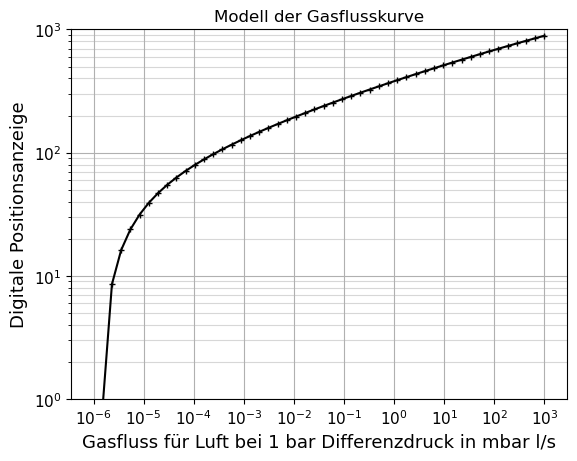

In [15]:
# Saugvermögen
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def f(x, a, b, c, d):
    return a*np.log10(x)**3 + b*np.log10(x)**2 + c*np.log10(x) + d

# log(f) = log(log(n, x)), weil eine log Kurve im log log plot

pos = np.array([2, 3, 10, 30, 40, 100, 300, 1000])
fluss = np.array([2e-6, 2e-6, 3e-6, 8e-6, 2e-5, 3e-4, 2e-1, 3e3])
p0 = (1, 1, 1, 1)

popt, pcov = curve_fit(f, fluss, pos, p0)

print(popt)
print(np.square(np.diag(pcov)))

a, b, c, d = 0.891884, 14.372, 118.6, 380

x = np.logspace(-6, 3)

fig, ax = plt.subplots()
ax.plot(x, f(x, a, b, c, d), "+-k", ms=4)

ax.loglog()
ax.set_ylim(1, 1000)

ax.set_xticks(np.logspace(-6,3,10))

ax.set_title("Modell der Gasflusskurve")
ax.set_xlabel("Gasfluss für Luft bei 1 bar Differenzdruck in mbar l/s", fontsize=13)
ax.set_ylabel("Digitale Positionsanzeige", fontsize=13)
ax.tick_params(labelsize=11)

ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.minorticks_on()

fig.savefig("../Bilder/vakuum/gasflussmodell.pdf")

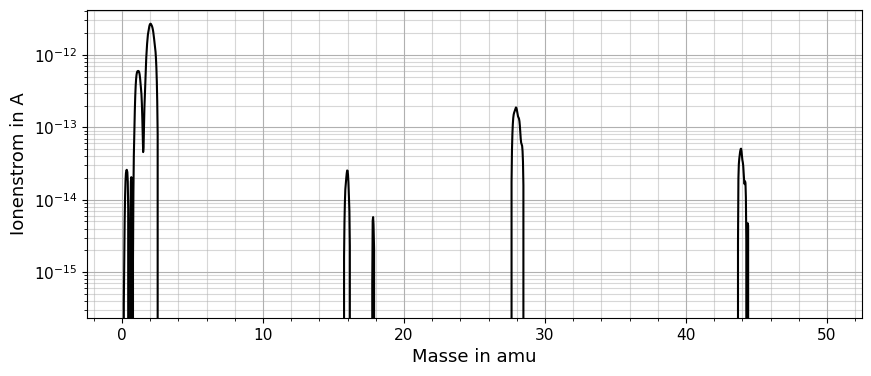

In [22]:
# Massenspektroskopie
import pandas as pd

restgas_data = pd.read_csv('../Messdaten/20260427_Vakuum/20260427 151445 Faraday Airdemo Scan Analog Restgas.asc', skiprows=19244, nrows=1600, decimal=',', delimiter='\t', index_col=False)

restgas_masse = restgas_data['Mass [amu]'].to_numpy()
restgas_ionenstrom = restgas_data['Ion Current [A]'].to_numpy()

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(restgas_masse, restgas_ionenstrom , "-k", ms=4, )

#ax.set_xticks(np.logspace(-6,3,10))
ax.set_xlabel("Masse in amu", fontsize=13)
ax.set_ylabel("Ionenstrom in A", fontsize=13)
ax.tick_params(labelsize=11)

ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.minorticks_on()
ax.set_yscale('log')

fig.savefig("../Bilder/vakuum/Massenspektrum_Restgas.pdf")

